# Credit Risk Prediction Model
## Dataset: loan_data_2007_2014

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Loan_Credit_Risk_Prediction

---

## 📌 Project Overview
This notebook performs final inference using the best model selected from the modeling phase,
LightGBM Tuned. It loads the trained model, applies it to the test set, and generates
final credit risk predictions for each borrower.

---

## 🎯 Objectives
- Load the trained LightGBM Tuned model
- Generate final predictions and default probability scores on the test set
- Export prediction results for business use and further analysis

---

## 🔍 Scope
The approach includes:
- Loading the saved LightGBM Tuned model using joblib
- Generating binary predictions and probability scores
- Producing a final output table with borrower risk classification
- Exporting results to CSV for downstream use

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Scikit-learn
- LightGBM
- Joblib

# Importing Library

In [2]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install optuna
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap
# Hyperparameter Tunning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Load Model

This section loads the trained LightGBM Tuned model saved during the modeling phase.

In [5]:
# Load saved LightGBM Tuned model
model_path = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\lgbm_tuned.pkl'
lgbm_tuned = joblib.load(model_path)

print("Model loaded successfully.")
print(f"Model type: {type(lgbm_tuned)}")

Model loaded successfully.
Model type: <class 'lightgbm.sklearn.LGBMClassifier'>


# 2. Load Test Set

This section loads the prepared test set from the Data Cleaning phase.

In [6]:
# Load test set
test_path = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\test_set.csv'
test = pd.read_csv(test_path)

# Separate features and target
X_test = test.drop(columns=['is_default'])
y_test = test['is_default']

print(f"Test set loaded: {test.shape}")
print(f"Features       : {X_test.shape[1]}")
print(f"Total samples  : {X_test.shape[0]:,}")
print(f"Default rate   : {y_test.mean() * 100:.2f}%")

Test set loaded: (46159, 95)
Features       : 94
Total samples  : 46,159
Default rate   : 19.09%


# 3. Generate Predictions

This section generates binary predictions and default probability scores
for each borrower in the test set using the loaded LightGBM Tuned model.

The approach includes:
- **Generating** binary predictions (0 = Good Loan, 1 = Bad Loan) and default probability scores
- **Building** a final prediction table combining actual labels, predicted labels, and probability scores
- **Classifying** each borrower into a risk category based on their default probability score

Risk categories are defined as follows:
- **Very Low**: default probability below 0.20
- **Low**: default probability between 0.20 and 0.40
- **Medium**: default probability between 0.40 and 0.60
- **High**: default probability between 0.60 and 0.80
- **Very High**: default probability above 0.80

In [7]:
# Generate predictions and probability scores
y_pred = lgbm_tuned.predict(X_test)
y_prob = lgbm_tuned.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(y_pred):,} borrowers.")
print(f"\nPrediction Distribution:")
print(f"  Good Loan (0): {(y_pred == 0).sum():,} ({(y_pred == 0).mean() * 100:.2f}%)")
print(f"  Bad Loan  (1): {(y_pred == 1).sum():,} ({(y_pred == 1).mean() * 100:.2f}%)")

Predictions generated for 46,159 borrowers.

Prediction Distribution:
  Good Loan (0): 28,663 (62.10%)
  Bad Loan  (1): 17,496 (37.90%)


In [8]:
# Build final prediction table
df_result = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'default_probability': y_prob.round(4)
})

# Add risk classification based on probability
df_result['risk_category'] = pd.cut(
    df_result['default_probability'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Add actual and predicted labels
df_result['actual_label'] = df_result['actual'].map({0: 'Good Loan', 1: 'Bad Loan'})
df_result['predicted_label'] = df_result['predicted'].map({0: 'Good Loan', 1: 'Bad Loan'})

print(f"\nSample Predictions:")
df_result.head(10)


Sample Predictions:


,actual,predicted,default_probability,risk_category,actual_label,predicted_label
0,0,1,0.6627,High,Good Loan,Bad Loan
1,0,0,0.2779,Low,Good Loan,Good Loan
2,0,0,0.3946,Low,Good Loan,Good Loan
3,0,0,0.3102,Low,Good Loan,Good Loan
4,0,1,0.6735,High,Good Loan,Bad Loan
5,1,0,0.3461,Low,Bad Loan,Good Loan
6,0,0,0.1568,Very Low,Good Loan,Good Loan
7,0,0,0.2498,Low,Good Loan,Good Loan
8,0,0,0.1478,Very Low,Good Loan,Good Loan
9,0,1,0.6322,High,Good Loan,Bad Loan


In [9]:
# Risk category distribution
print("Risk Category Distribution:")
print(df_result['risk_category'].value_counts().sort_index())

Risk Category Distribution:
risk_category
Very Low      5796
Low          15208
Medium       14493
High          9531
Very High     1131
Name: count, dtype: int64


# 4. Export Results

This section compiles the final prediction results and exports them for business use.
The output includes default probability score, risk category, and predicted label
for each borrower in the test set.

In [10]:
# Sort by default probability descending
df_result = df_result.sort_values('default_probability', ascending=False).reset_index(drop=True)

print(f"Final results shape: {df_result.shape}")
print(f"\nSample results (Top 10 highest risk):")
df_result.head(10)

Final results shape: (46159, 6)

Sample results (Top 10 highest risk):


,actual,predicted,default_probability,risk_category,actual_label,predicted_label
0,1,1,0.9361,Very High,Bad Loan,Bad Loan
1,1,1,0.9293,Very High,Bad Loan,Bad Loan
2,0,1,0.9210,Very High,Good Loan,Bad Loan
3,0,1,0.9188,Very High,Good Loan,Bad Loan
4,0,1,0.9177,Very High,Good Loan,Bad Loan
5,1,1,0.9159,Very High,Bad Loan,Bad Loan
6,1,1,0.9139,Very High,Bad Loan,Bad Loan
7,0,1,0.9136,Very High,Good Loan,Bad Loan
8,1,1,0.9131,Very High,Bad Loan,Bad Loan
9,1,1,0.9119,Very High,Bad Loan,Bad Loan


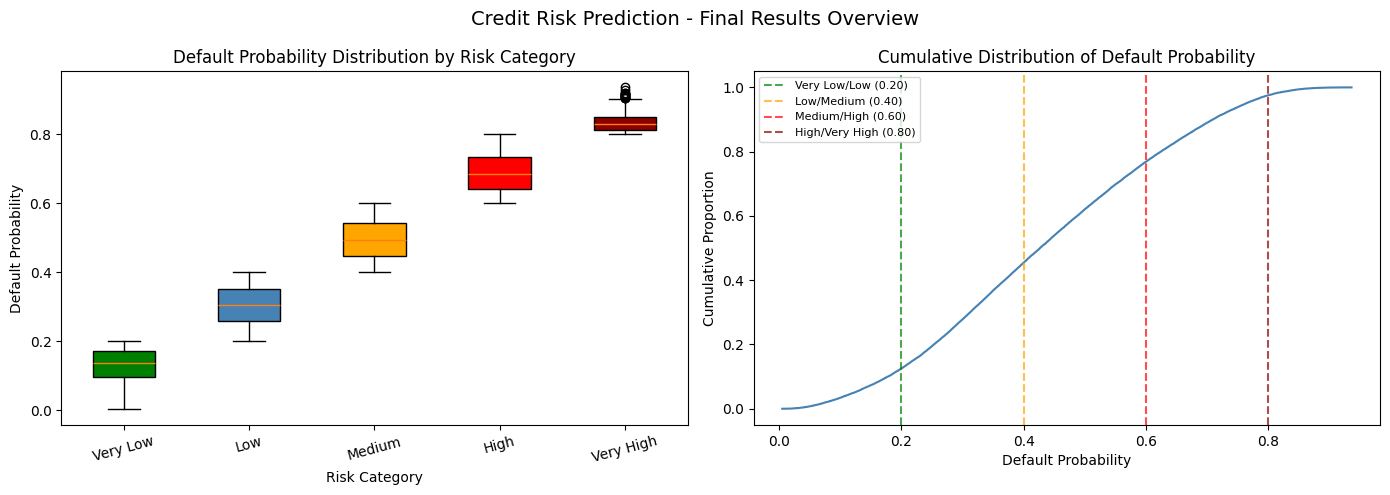

In [11]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'Very Low': 'green', 'Low': 'steelblue',
    'Medium': 'orange', 'High': 'red', 'Very High': 'darkred'
}
tier_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

data_by_tier = [
    df_result[df_result['risk_category'] == tier]['default_probability'].values
    for tier in tier_order
]
bp = axes[0].boxplot(data_by_tier, labels=tier_order, patch_artist=True)
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(colors[tier])
axes[0].set_title('Default Probability Distribution by Risk Category')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Default Probability')
axes[0].tick_params(axis='x', rotation=15)

sorted_probs = np.sort(df_result['default_probability'].values)
cumulative = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)
axes[1].plot(sorted_probs, cumulative, color='steelblue')
axes[1].axvline(x=0.2, color='green', linestyle='--', alpha=0.7, label='Very Low/Low (0.20)')
axes[1].axvline(x=0.4, color='orange', linestyle='--', alpha=0.7, label='Low/Medium (0.40)')
axes[1].axvline(x=0.6, color='red', linestyle='--', alpha=0.7, label='Medium/High (0.60)')
axes[1].axvline(x=0.8, color='darkred', linestyle='--', alpha=0.7, label='High/Very High (0.80)')
axes[1].set_title('Cumulative Distribution of Default Probability')
axes[1].set_xlabel('Default Probability')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].legend(fontsize=8)

plt.suptitle('Credit Risk Prediction - Final Results Overview', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Export to CSV
output_path = r'D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\prediction_results.csv'
df_result.to_csv(output_path, index=False)

print(f"Results saved successfully!")
print(f"Path  : {output_path}")
print(f"Total : {len(df_result):,} borrowers scored")
print(f"\nFinal Risk Category Summary:")
for tier in tier_order:
    count = len(df_result[df_result['risk_category'] == tier])
    pct = count / len(df_result) * 100
    print(f"  {tier:<12}: {count:,} ({pct:.2f}%)")

Results saved successfully!
Path  : D:\Python\Projects\Project Idxpartners Credit Risk Prediction Model\Loan_Credit_Risk_Prediction\prediction_results.csv
Total : 46,159 borrowers scored

Final Risk Category Summary:
  Very Low    : 5,796 (12.56%)
  Low         : 15,208 (32.95%)
  Medium      : 14,493 (31.40%)
  High        : 9,531 (20.65%)
  Very High   : 1,131 (2.45%)


In [13]:
# Get accurate statistics per risk category
print(df_result.groupby('risk_category')['default_probability'].agg(['count', 'mean', 'min', 'max']).round(4))

               count    mean     min     max
risk_category                               
Very Low        5796  0.1312  0.0050  0.2000
Low            15208  0.3049  0.2001  0.4000
Medium         14493  0.4964  0.4001  0.6000
High            9531  0.6885  0.6001  0.8000
Very High       1131  0.8340  0.8002  0.9361


### Key Findings

**Final Output**
Credit risk prediction results successfully generated for **46,159 borrowers** with
default probability scores ranging from 0.0050 to 0.9361.

**Risk Category Summary**
| Risk Category | Count | Percentage | Avg Probability | Min | Max |
|---|---|---|---|---|---|
| Very Low | 5,796 | 12.56% | 0.1312 | 0.0050 | 0.2000 |
| Low | 15,208 | 32.95% | 0.3049 | 0.2001 | 0.4000 |
| Medium | 14,493 | 31.40% | 0.4964 | 0.4001 | 0.6000 |
| High | 9,531 | 20.65% | 0.6885 | 0.6001 | 0.8000 |
| Very High | 1,131 | 2.45% | 0.8340 | 0.8002 | 0.9361 |

**Highest Risk Borrowers**
The highest risk borrower has a default probability of **0.9361**, indicating extremely
high likelihood of default. The top 10 highest risk borrowers all show probabilities
above 0.91, warranting immediate rejection or substantial collateral requirements.

**Score Distribution Interpretation**
The cumulative distribution confirms that approximately 13% of borrowers fall below
the 0.20 threshold, 46% below 0.40, and 97.5% below 0.80. This distribution reflects
a moderately risky portfolio consistent with the 19.09% default rate in the test set.

**Business Action by Risk Category**
- **Very Low**: Approve with standard loan terms
- **Low**: Approve with standard monitoring
- **Medium**: Approve with enhanced monitoring or adjusted repayment schedule
- **High**: Require additional documentation, reduce principal, or increase collateral
- **Very High**: Reject application or require substantial collateral and co-signer

**Results saved to** `prediction_results.csv`

---